In [1]:
%run ~/analysisLibraries

In [2]:
%matplotlib inline

In [3]:
%load_ext rpy2.ipython

## Read data containing all necessary scores and relevant genes calculated in the previous notebook

In [4]:
adata = sc.read('./write/SDA_object_100comps.h5ad')

component can be changed using the software papermill to execute notebooks in the workflow

In [5]:
comp=0

In [6]:
# Parameters
comp = 32


## Open SDA matrices

In [7]:
A = pd.read_csv('ALLDATA_scaled_onematrix_data_100comps/it2000/A', sep=' ', header=None)
#B is only for multi-tissues tensor
#B = pd.read_csv('SDA/CELLS_sctransform_onematrix_data/it2000/B1', sep=' ', header=None)
X = pd.read_csv('ALLDATA_scaled_onematrix_data_100comps/it2000/X1', sep=' ', header=None)

$A$ contains the score of each cell in the components. This score can be used as a "soft clustering" once it is normalized. We will try to do that in the notebook that follows this one. 

In [8]:
A.shape

(10548, 100)

In [9]:
A.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.237044,-0.444741,-0.521709,-0.421176,-0.191632,-0.039443,-0.011519,0.313026,-0.017442,-0.014353,...,-0.713952,0.084345,0.325848,0.577062,-0.704971,-0.307896,0.102466,-0.919935,-0.196817,-1.101270
1,0.411126,-0.113899,-0.404359,-0.412903,0.112982,-0.168036,-0.364643,0.746365,-0.003497,-0.242012,...,0.923655,-0.432896,0.018581,-0.329805,-0.004898,-0.298961,0.290554,0.328762,-0.211422,0.605521
2,-0.554124,-2.115210,0.572701,-0.509780,0.577237,-0.234850,0.450509,0.208679,0.177719,-0.164977,...,-0.382789,0.511820,0.686443,0.116738,-0.315359,-0.109686,1.740900,-0.937221,0.846761,0.562644
3,-0.258430,1.402740,1.303190,-0.759115,1.298820,-0.058847,-0.725280,-0.359907,0.306425,1.195000,...,-0.727815,0.416148,2.020470,-0.108066,-0.465147,-1.716540,0.712520,-0.855888,0.907461,0.266163
4,-0.338097,1.336100,-1.538940,0.907896,0.817900,1.415150,-0.130066,-0.545487,-0.755909,-0.912024,...,-1.259190,-0.325736,0.157799,1.454890,-0.115039,-0.391225,1.149520,0.961979,-0.198099,0.624347


In [10]:
#B

$X$ contains the loading of each gene in each component according to the spike-and-slab prior. The sign of the loading has to be considered together with the sign of the cell score to see if the resulting sign is positive (significant expression of gene) or negative (significant underexpression of gene)

In [11]:
X.columns = adata[:,(np.log(adata.var['variance-Cells'])>0)|(np.log(adata.var['variance-Nuclei']>-1))].var_names

In [12]:
X.shape

(100, 6276)

In [13]:
X.head()

,AURKAIP1,MRPL20,SSU72,LOC469457,GNB1,MORN1,RER1,MMEL1,ACTRT2,CCDC27,...,amplicon-chrX-FAM9A/B/C-6,amplicon-chrX-GAGE10-0,amplicon-chrX-LOC107966365-0,amplicon-chrX-LOC112206844-0,amplicon-chrX-LOC112206844-2,amplicon-chrX-LOC112206844-4,amplicon-chrX-LOC465705-2,amplicon-chrX-PAGE5-3,amplicon-chrX-SPANXN5-2,amplicon-chrX-SSX1/3/2B-15
0,-0.251518,-0.050381,-0.000772,-0.082587,-0.000094,-0.001789,-0.132522,0.000048,-0.053861,-0.035661,...,0.000333,0.000363,-0.000149,-0.036358,-0.000366,0.002521,-0.061503,0.000056,0.000141,0.006134
1,0.000395,0.000193,-0.000607,0.001750,0.000787,-0.001956,-0.000217,-0.000121,0.000535,-0.000017,...,0.066423,-0.000271,0.000069,0.029602,0.001012,0.000030,-0.000178,0.000639,-0.026457,0.000855
2,-0.000250,-0.000108,-0.000195,0.030246,0.000202,-0.001048,-0.000112,0.000151,-0.001854,-0.000145,...,-0.000141,0.001418,-0.000997,-0.000141,-0.039148,-0.000122,0.000968,-0.000012,-0.001109,0.000334
3,0.000423,-0.000399,-0.000322,0.002582,0.000288,0.000177,-0.000765,0.046786,0.000218,0.000263,...,-0.000404,0.000993,0.000137,0.000224,0.043691,-0.000044,0.000219,0.000187,0.000062,-0.000340
4,-0.000056,-0.000013,0.000059,-0.000223,0.033124,-0.000006,0.000276,-0.107145,0.000001,-0.051293,...,-0.034791,0.000032,0.061013,-0.000074,-0.000050,0.000003,0.000006,0.000007,-0.000034,-0.037562


## Some plots and measures about the specific components

#### UMAP of cell scores and batches

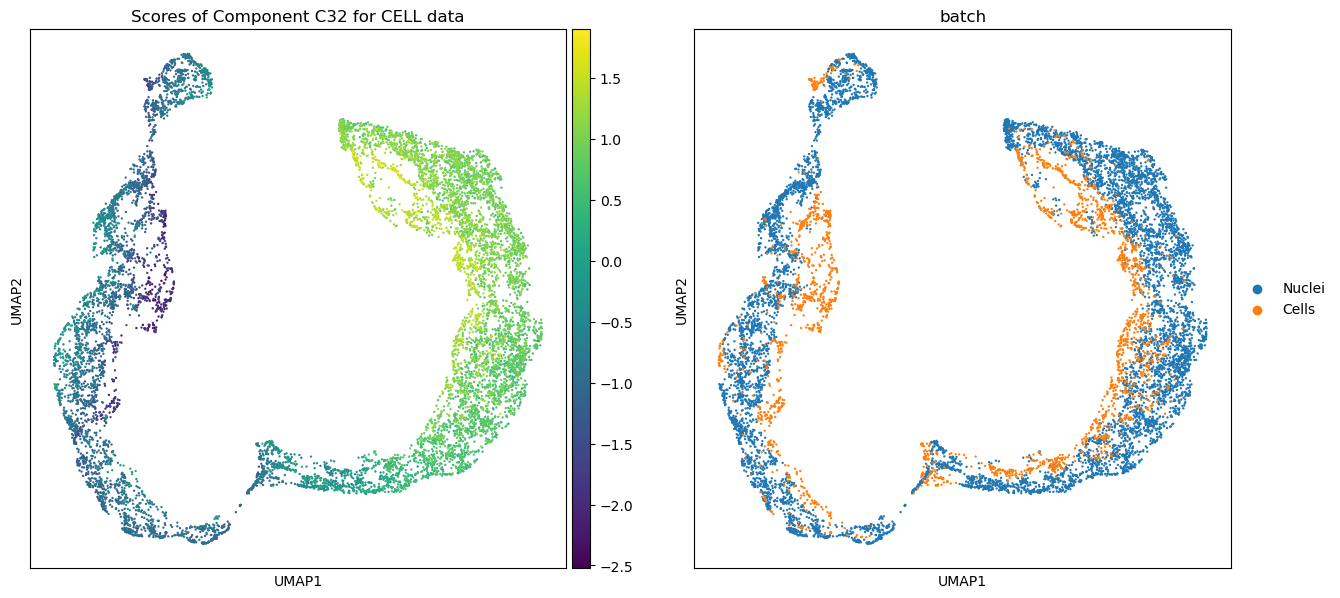

In [14]:
plt.rcParams['figure.figsize']=(7,7)
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}','batch'],
          title=f'Scores of Component C{comp} for CELL data')

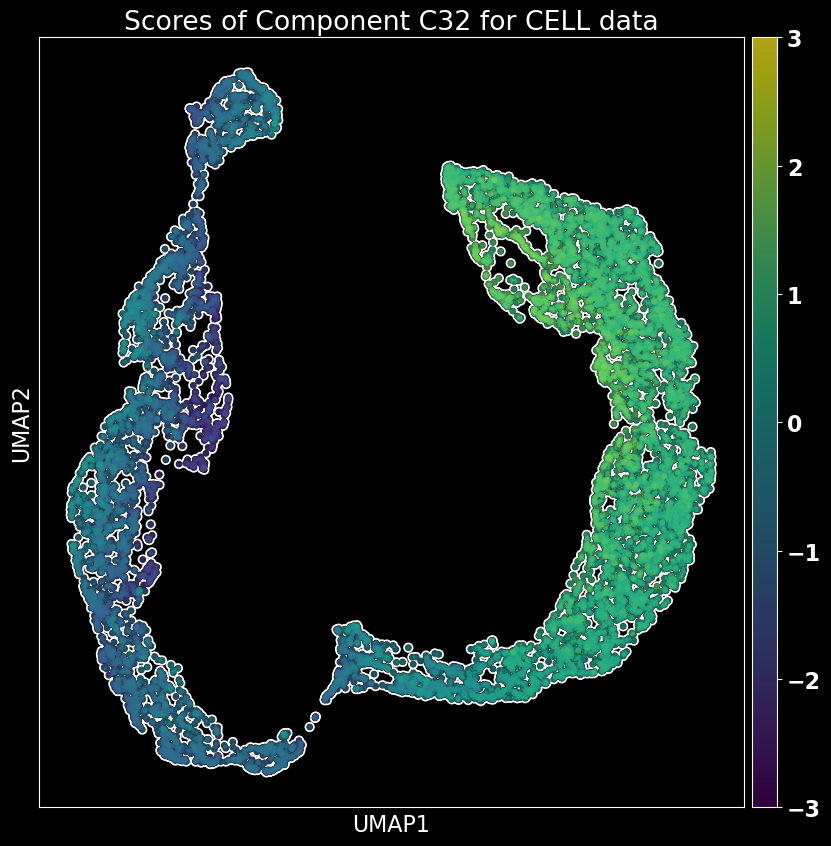

In [15]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('dark_background')
plt.rc('font', size=16, weight='bold')
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}'], vmin=-3, vmax=3, 
          title=f'Scores of Component C{comp} for CELL data', size=75,
          add_outline=True, outline_color=['white','black'],
          save=f'scores_C{comp}_dark.png', )

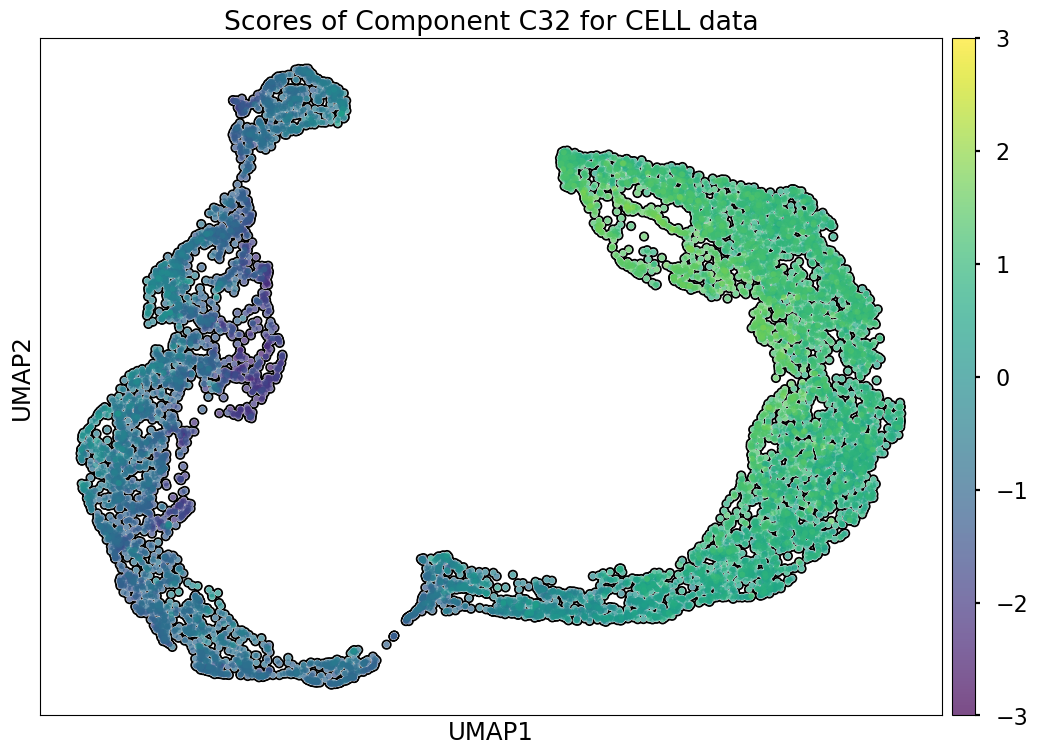

In [16]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}'], vmin=-3, vmax=3, 
          title=f'Scores of Component C{comp} for CELL data', size=75,
          add_outline=True,
          save=f'scores_C{comp}_white.png', )

In [17]:
try:
    IRRELEVANT=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['IRRELEVANT']
except Exception as e:
    IRRELEVANT=0
try:
    POSITIVE=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['POSITIVE']
except Exception as e:
    POSITIVE=0
try:
    NEGATIVE=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['NEGATIVE']
except Exception as e:
     NEGATIVE=0

In [18]:
onlyrelevant = np.array( adata.obs[f'sda_cell_relevant_C{comp}'].copy() )
onlyrelevant[onlyrelevant=='IRRELEVANT']=None
adata.obs[f'sda_cell_relevantonly_C{comp}'] = onlyrelevant

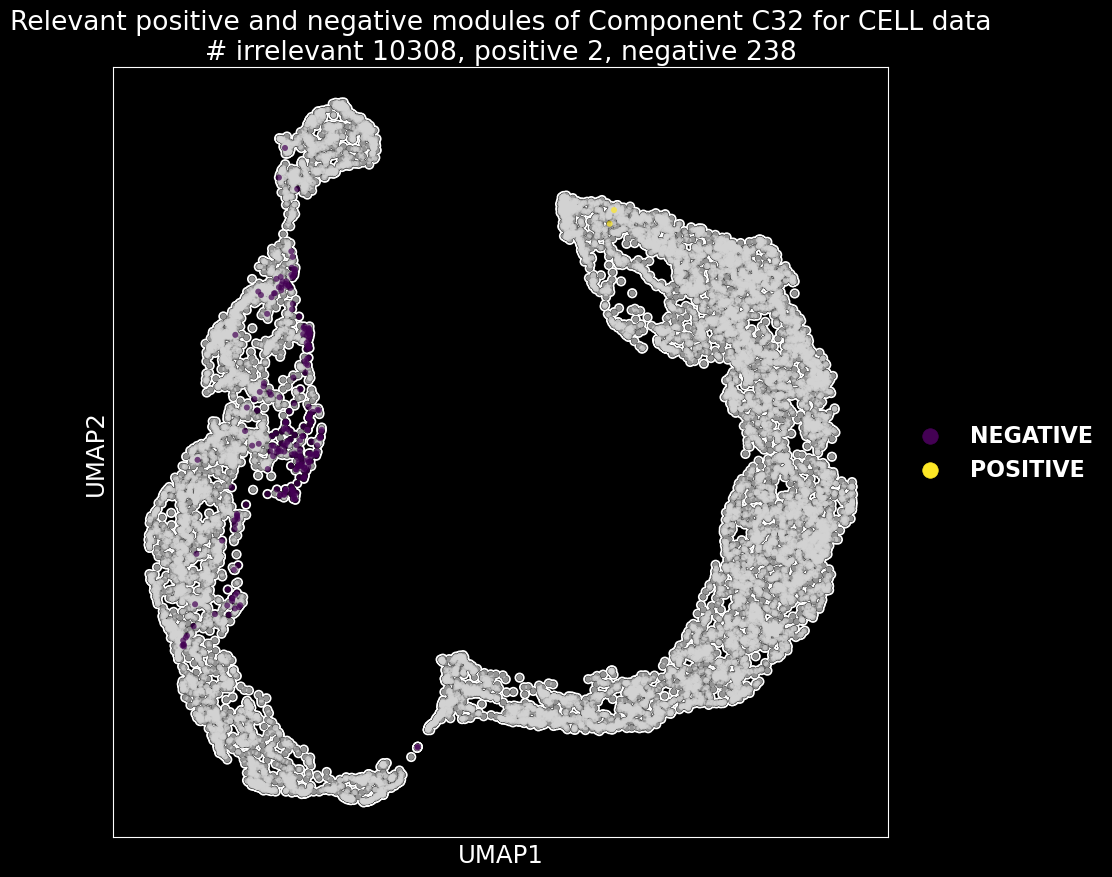

In [19]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('dark_background')
plt.rc('font', size=16, weight='bold')
sc.pl.umap(adata, color=[f'sda_cell_relevantonly_C{comp}'], vmin=-3, vmax=3, na_in_legend=False, na_color='lightgray',
          title=f'Relevant positive and negative modules of Component C{comp} for CELL data\n# irrelevant {IRRELEVANT}, positive {POSITIVE}, negative {NEGATIVE}', 
          size=75, add_outline=True, outline_color=['white','black'], palette='viridis',
          save=f'relevance_C{comp}_dark.png')

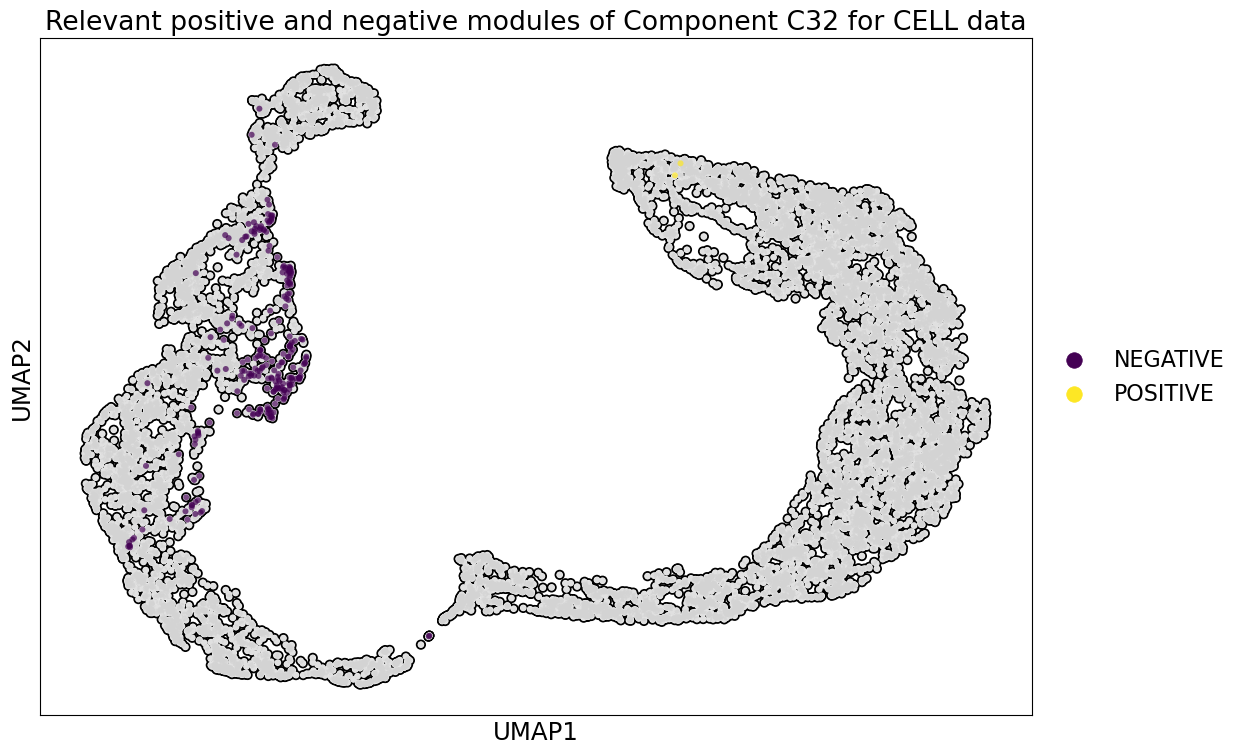

In [20]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'sda_cell_relevantonly_C{comp}'], vmin=-3, vmax=3, na_in_legend=False, na_color='lightgray',
          title=f'Relevant positive and negative modules of Component C{comp} for CELL data', palette='viridis',
          size=75, add_outline=True,
          save=f'relevance_C{comp}_white.png')

### mean and std of positive and negative cell scores for each batch

In [21]:
score_cells = adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}']
score_nuclei = adata[adata.obs['batch']=='Nuclei'].obs[f'SDA_cellscore_C{comp}']

In [22]:
print( 'Positive scores nuclei - mean:', np.mean(score_nuclei[score_nuclei>1.5]), 'var:', np.std(score_nuclei[score_nuclei>1.5])  )
print( 'Positive scores cells  - mean:', np.mean(score_cells[score_cells>2]), 'var:', np.std(score_cells[score_cells>2])  )

Positive scores nuclei - mean: 1.6234950000000001 var: 0.03923500000000002
Positive scores cells  - mean: nan var: nan


In [23]:
print( 'Negative scores nuclei - mean:', np.mean(score_nuclei[score_nuclei<-1.5]), 'var:', np.std(score_nuclei[score_nuclei<-1.5])  )
print( 'Negative scores cells  - mean:', np.mean(score_cells[score_cells<-2]), 'var:', np.std(score_cells[score_cells<-2])  )

Negative scores nuclei - mean: -1.6142913559322034 var: 0.09055168340595869
Negative scores cells  - mean: -2.16298156424581 var: 0.1273082703050196


### T-test to detect batch differences in a module

We check if positive/negative scores are specific for either cells or genes, so we can highlight that in our information output

In [24]:
import scipy

Two-sided test of positive scores of cells vs nuclei

In [25]:
scipy.stats.ttest_ind( score_cells[score_cells>0], score_nuclei[score_nuclei>0])

Ttest_indResult(statistic=40.458574362614705, pvalue=0.0)

Two-sided test of negative scores of cells vs nuclei

In [26]:
scipy.stats.ttest_ind( score_cells[score_cells<0], score_nuclei[score_nuclei<0])

Ttest_indResult(statistic=-35.6951859494058, pvalue=5.265257448163214e-248)

Cells have more transcripts than nuclei and this is reflected in a bit higher/lower score in general, so we choose a strict threshold to avoid detecting batch differences where they are mostly due to technical causes

In [27]:
pos_stat, pos_p = scipy.stats.ttest_ind( score_cells[score_cells>0], score_nuclei[score_nuclei>0])
neg_stat, neg_p = scipy.stats.ttest_ind( score_cells[score_cells<0], score_nuclei[score_nuclei<0])

batch_effect_pos='No'
batch_effect_neg='No'

if np.abs(pos_stat) > 10:
    batch_effect_pos='Yes'
print(f'Positive module batch differences: {batch_effect_pos}')
    
if np.abs(neg_stat) > 10:
    batch_effect_neg='Yes'
print(f'Negative module batch differences: {batch_effect_neg}')

Positive module batch differences: Yes
Negative module batch differences: Yes


<Axes: xlabel='SDA_cellscore_C32', ylabel='Count'>

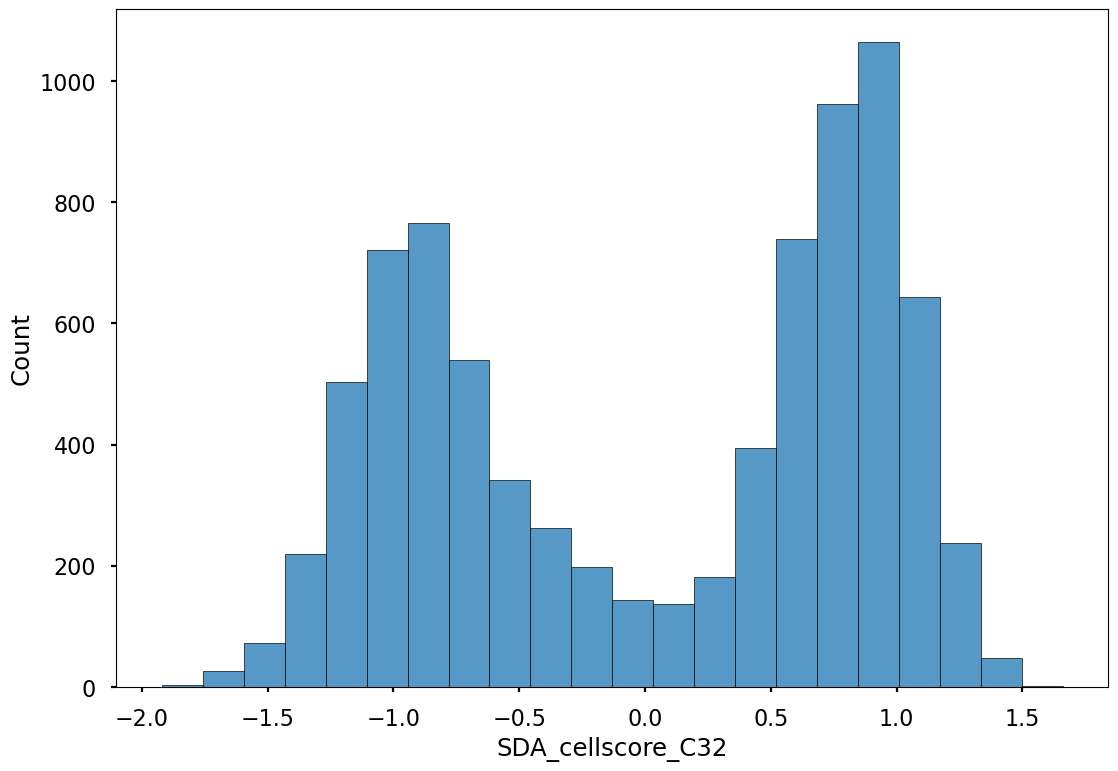

In [28]:
plt.rcParams['figure.figsize']=(6,6)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sns.histplot(adata[adata.obs['batch']=='Nuclei'].obs[f'SDA_cellscore_C{comp}'])

<Axes: xlabel='SDA_cellscore_C32', ylabel='Count'>

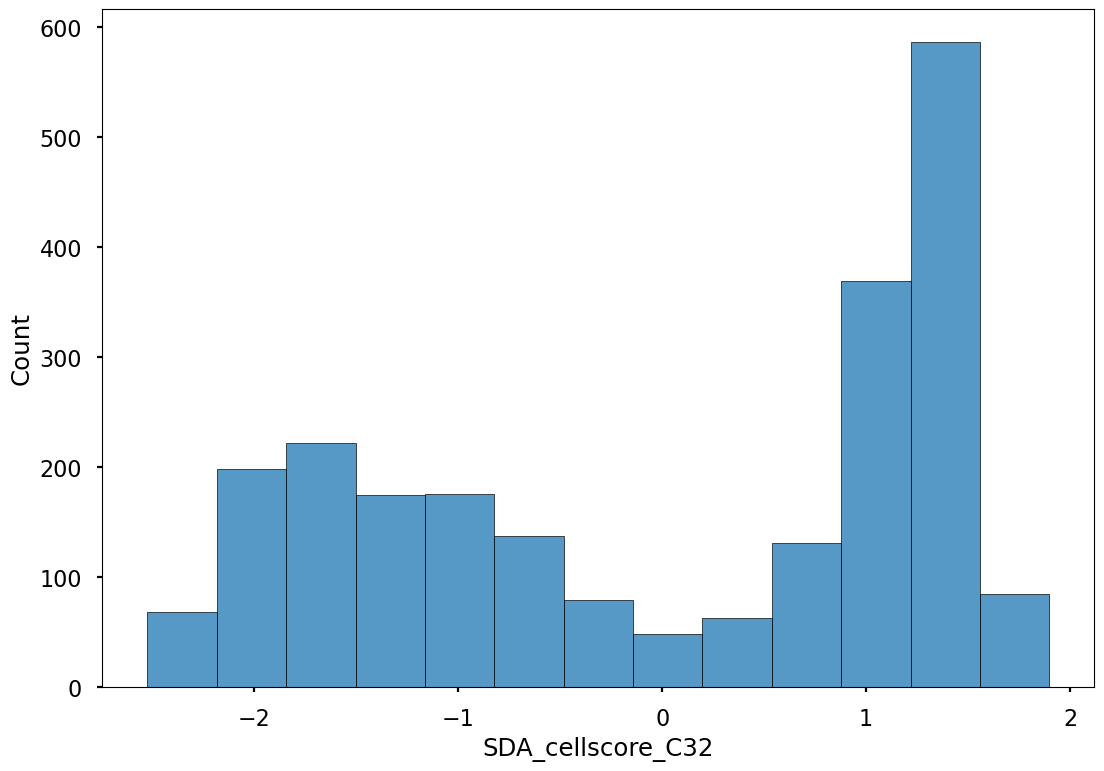

In [29]:
sns.histplot(adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'])

Genes significant for components (whole list printed to easy copy-pase for onlyne databases):

In [30]:
print(f'Genes significant for positive C{comp}:', adata[:,adata.var[f'sda_pos_C{comp}']].shape[1])

Genes significant for positive C32: 862


In [31]:
for i in adata[:,adata.var[f'sda_pos_C{comp}']].var_names:
    print(i)

MMEL1
ACTRT2
CCDC27
CHD5
TTLL10
LOC107974981
EFHD2
MINOS1
EPHB2
TEX46
ZNF683
HMGB4
LOC104007285
TEKT2
LOC104007435
TMCO2
KIF2C
NSUN4
TEX38
ELAVL4
C1H1orf185
TTC39A
LEXM
LOC107966822
LOC112204431
JAK1
LOC107967064
TNNI3K
SLC44A5
DNAJB4
LRRC8C
LOC741368
MFSD14A
CDC14A
VAV3
AKNAD1
LOC107967559
C1H1orf194
KIAA1324
UBL4B
LRIF1
DDX20
PPM1J
LOC100614375
LOC746061
LOC749061
OTUD7B
PLEKHO1
SMCP
LELP1
TPM3
MTX1
LOC107968824
ATP1A4
KLHDC9
NOS1AP
SPATA46
MAEL
PRRX1
METTL13
TNR
TEX35
TOR1AIP1
RGSL1
LOC107973782
LOC107969611
GLRX2
ETNK2
LEMD1
CD55
SLC30A1
SUSD4
LOC112206648
LOC107970640
TARBP1
LOC107970667
LGALS8
LOC100613624
ACP1
LOC104004841
LOC112208151
ALLC
DCDC2C
LOC100615276
LPIN1
MAPRE3
LOC104004917
C2AH2orf16
CCDC121
CLIP4
DHX57
MORN2
PRKCE
TTC7A
CFAP36
LOC107973470
C2AH2orf74
LOC107973474
LOC107973482
EHBP1
PELI1
GMCL1
HK2
CTNNA2
TEX37
CHCHD5
FER1L5
VWA3B
RNF149
C2AH2orf40
TEX51
LOC104005193
KIF5C
LYPD6B
GPD2
ERICH2
FKBP7
PLEKHA3
TTN
LOC104005277
CCDC141
LOC107973852
PDE1A
PMS1
INPP1
MFSD6


In [32]:
print(f'Genes significant for negative C{comp}:', adata[:,adata.var[f'sda_neg_C{comp}']].shape[1])

Genes significant for negative C32: 984


In [33]:
for i in adata[:,adata.var[f'sda_neg_C{comp}']].var_names:
    print(i)

MRPL20
LOC469457
GNB1
NPHP4
PARK7
RERE
SLC25A33
MTOR
C1H1orf167
VPS13D
SDHB
MRTO4
HP1BP3
CDC42
SRSF10
WASF2
EYA3
EPB41
SNRNP40
RBBP4
ZMYM6
CLSPN
AGO4
AGO3
THRAP3
MEAF6
FOXJ3
RPS8
PRDX1
NASP
GPBP1L1
LOC742376
EFCAB14
FAF1
EPS15
ZFYVE9
ZCCHC11
TMEM59
TM2D1
ATG4C
ITGB3BP
ZRANB2
LOC104001211
ACADM
MSH4
PIGK
ZZZ3
USP33
ZNHIT6
COL24A1
SH3GLB1
HS2ST1
ZNF326
ZNF644
RPAP2
EVI5
MTF2
PTBP2
LOC104001730
SORT1
RAP1A
DENND2C
LOC112208396
VPS45
PSMD4
ASH1L
YY1AP1
GON4L
SSR2
ARHGEF11
TIPRL
PRRC2C
RABGAP1L
RALGPS2
ABL2
DHX9
RGL1
ODR4
LOC112206075
ASPM
CRB1
NEK7
MDM4
SRGAP2
DTL
RPS6KC1
MIA3
SRP9
ARF1
PCNX2
HEATR1
MTR
ADSS
EFCAB2
EIPR1
RNF144A
KIDINS220
MBOAT2
ADAM17
YWHAQ
TAF1B
PDIA6
ROCK2
LOC104004883
VSNL1
TTC32
PUM2
ATAD2B
UBXN2A
ITSN2
NCOA1
DTNB
ASXL2
RAB10
HADHA
MEMO1
SPAST
BIRC6
STRN
GPATCH11
PRKD3
EML4
MCFD2
MSH2
MSH6
FBXO11
NRXN1
ASB3
CCDC88A
LOC104004979
FANCL
XPO1
CCT4
UGP2
ACTR2
AAK1
ANXA4
ZNF638
ALMS1
KCMF1
USP39
TMEM87B
SEPT10
KANSL3
TMEM131
LOC746383
ACTR3
EPB41L5
NIFK
MAP3K2
IWS1
SAP130
Z

#### Cells scores by cluster

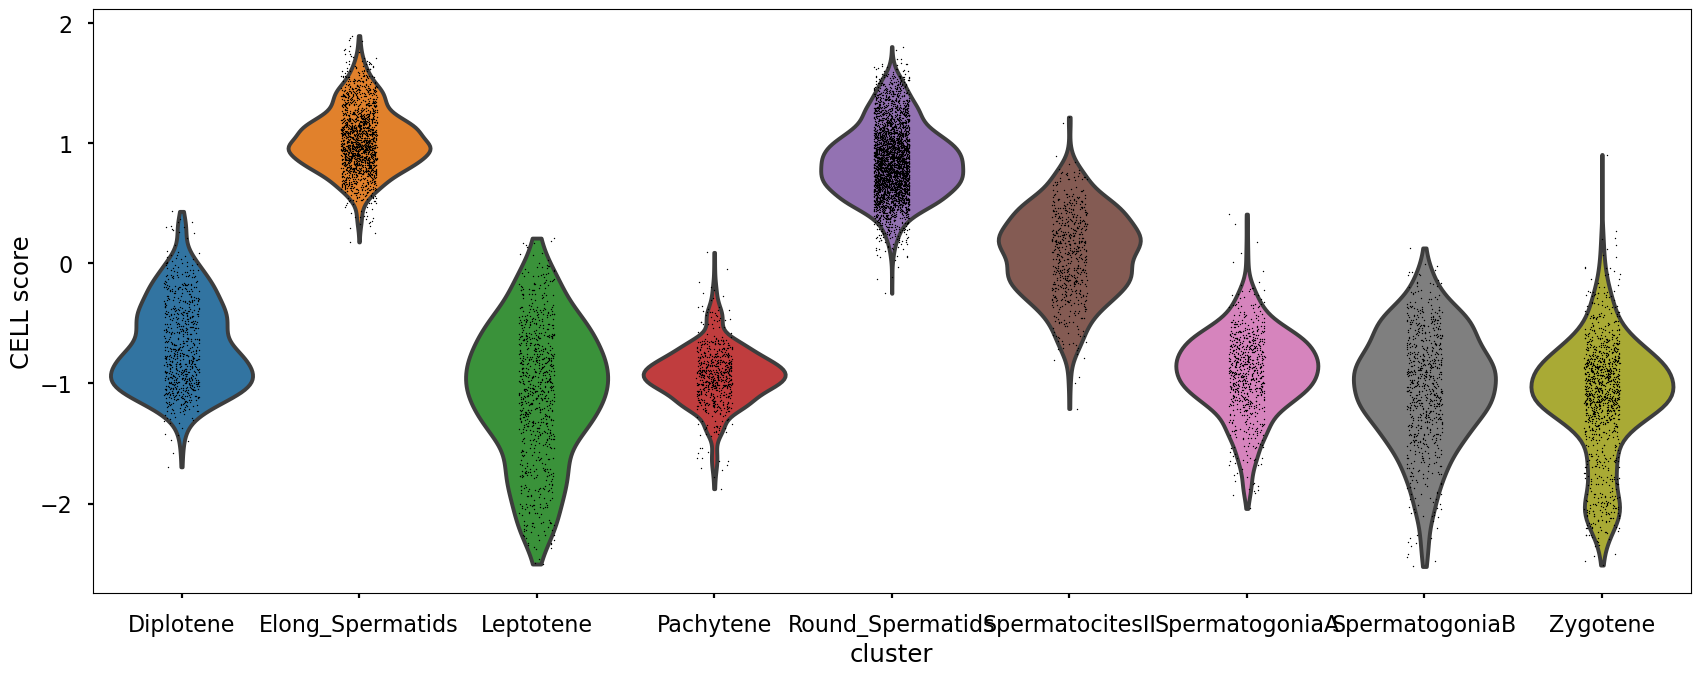

In [34]:
plt.rcParams['figure.figsize']=(16,8)
sc.pl.violin(adata, 
             groupby='spermatogenesis', keys=f'SDA_cellscore_C{comp}',
             title=f'CELLS score for SDA component C{comp}',
             xlabel='cluster', ylabel='CELL score')

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(0, 0, 'SpermatogoniaA'),
  Text(1, 0, 'SpermatogoniaB'),
  Text(2, 0, 'Leptotene'),
  Text(3, 0, 'Zygotene'),
  Text(4, 0, 'Pachytene'),
  Text(5, 0, 'Diplotene'),
  Text(6, 0, 'SpermatocitesII'),
  Text(7, 0, 'Round_Spermatids'),
  Text(8, 0, 'Elong_Spermatids')])

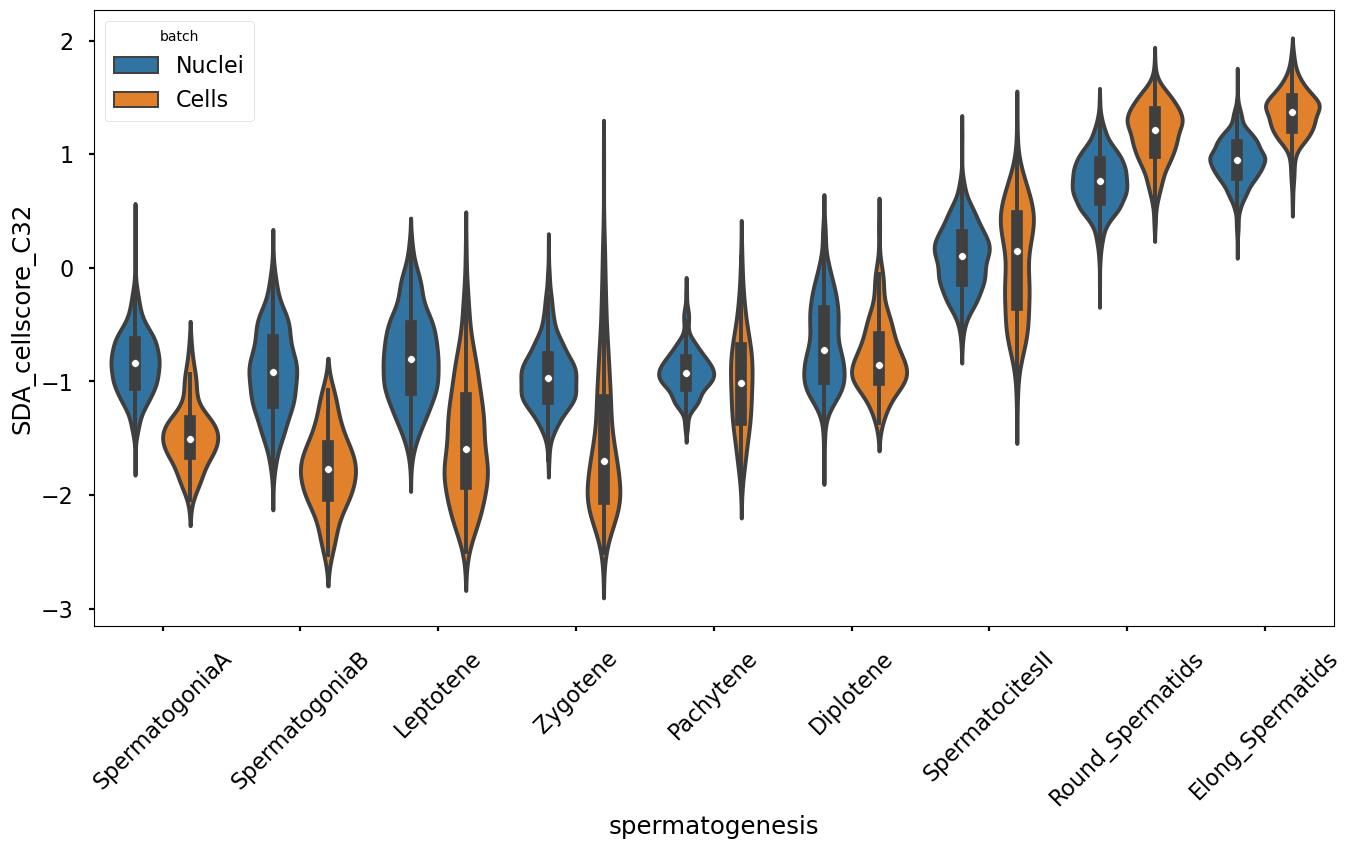

In [35]:
plt.rcParams['figure.figsize']=(16,8)
sns.violinplot(x='spermatogenesis', y=f'SDA_cellscore_C{comp}', hue='batch', data=adata.obs, 
               order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids'])
plt.xticks(rotation=45)

#### Cell scores by pseudotimes and relative threshold lines

In [36]:
score_neg = -2 #min( -2, np.quantile(A[int(comp)], .1) )
score_pos = 2 #max( +2, np.quantile(A[int(comp)], .9) )

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C32')

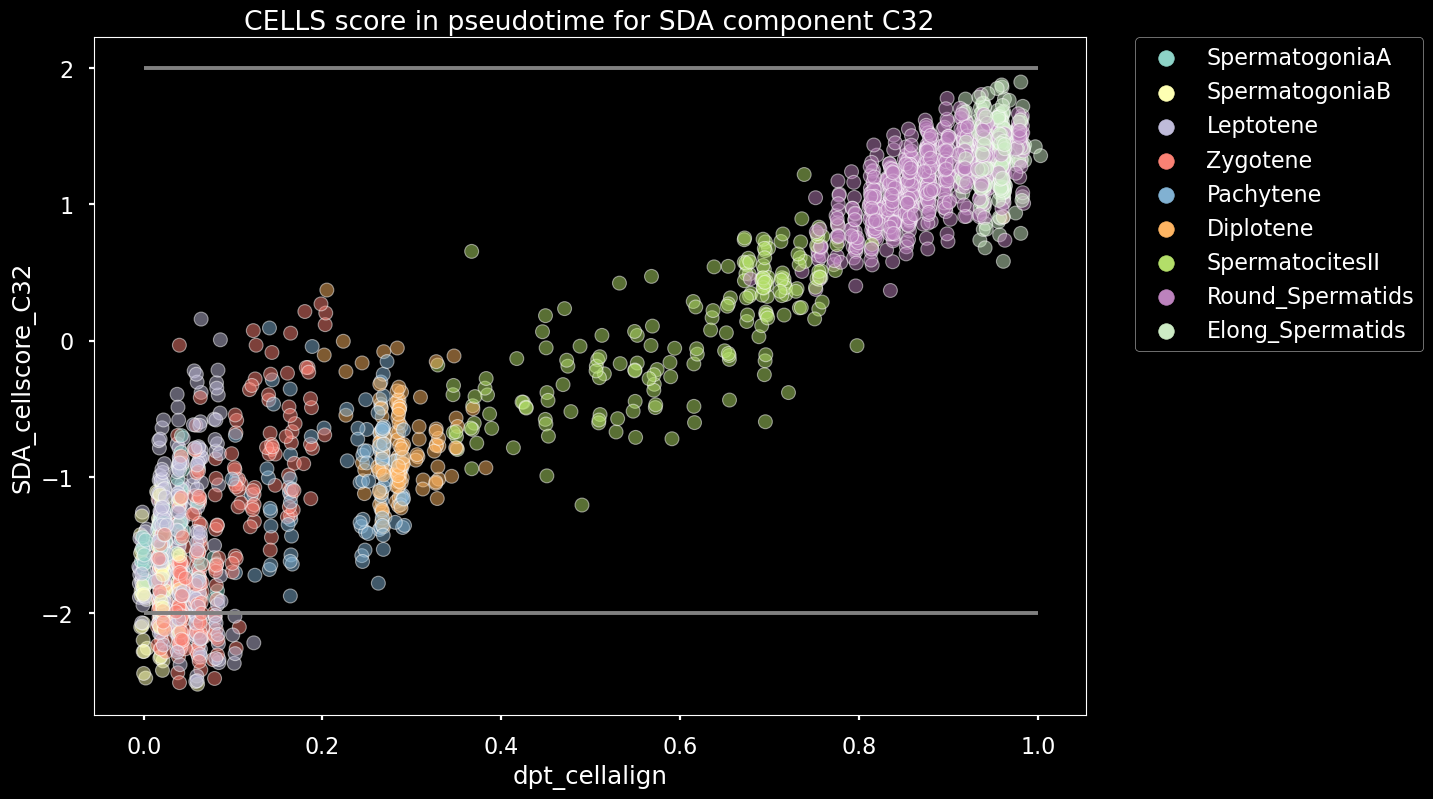

In [37]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'], 
           x=adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata[adata.obs['batch']=='Cells'].shape[0]),
           hue=adata[adata.obs['batch']=='Cells'].obs['spermatogenesis'],
           alpha=.5, ax=ax, s=100,
           hue_order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 
                      'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids']
           )
plt.hlines(score_neg, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C32')

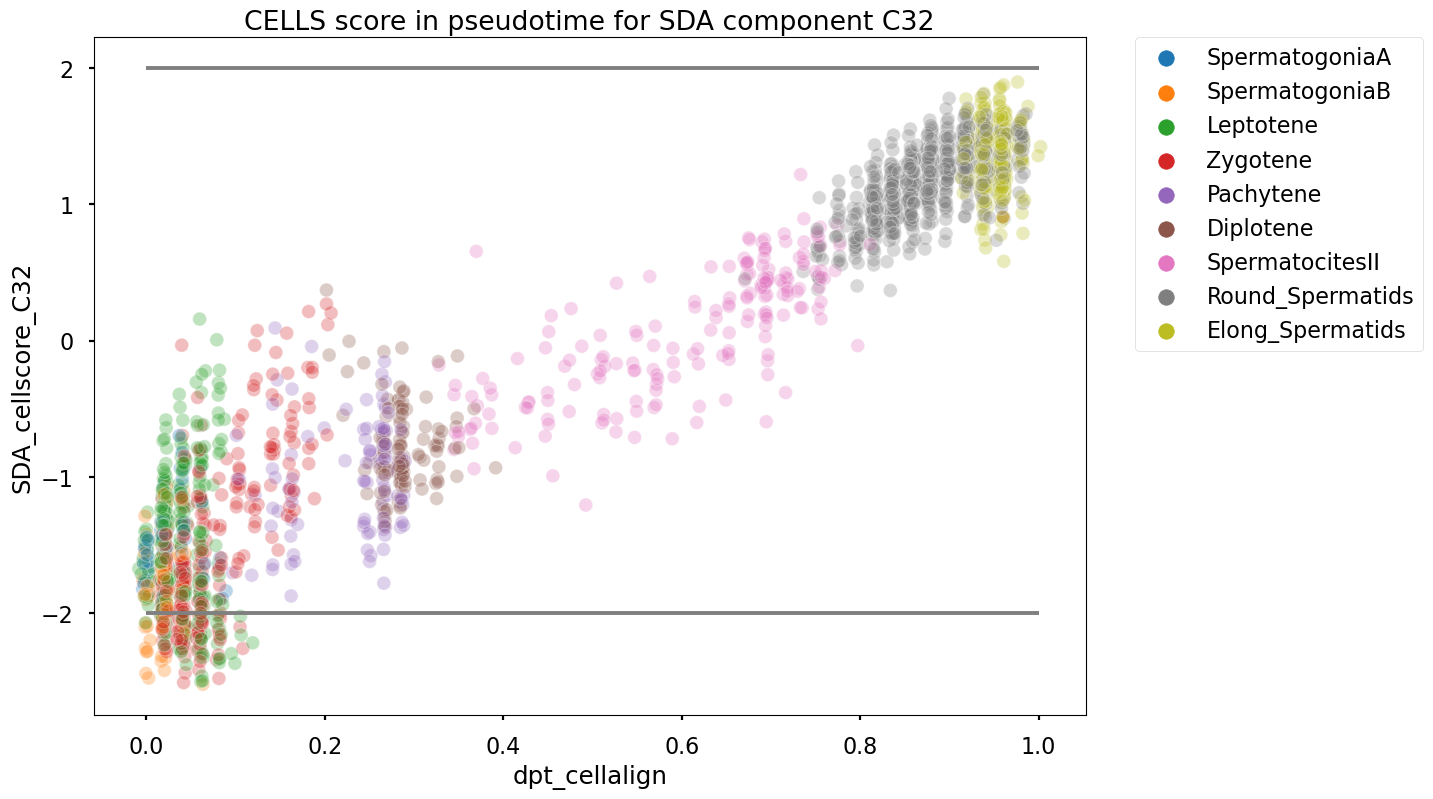

In [38]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'], 
           x=adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata[adata.obs['batch']=='Cells'].shape[0]),
           hue=adata[adata.obs['batch']=='Cells'].obs['spermatogenesis'],
           alpha=.3, ax=ax, s=100,
           hue_order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 
                      'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids']
           )
plt.hlines(score_neg, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C32')

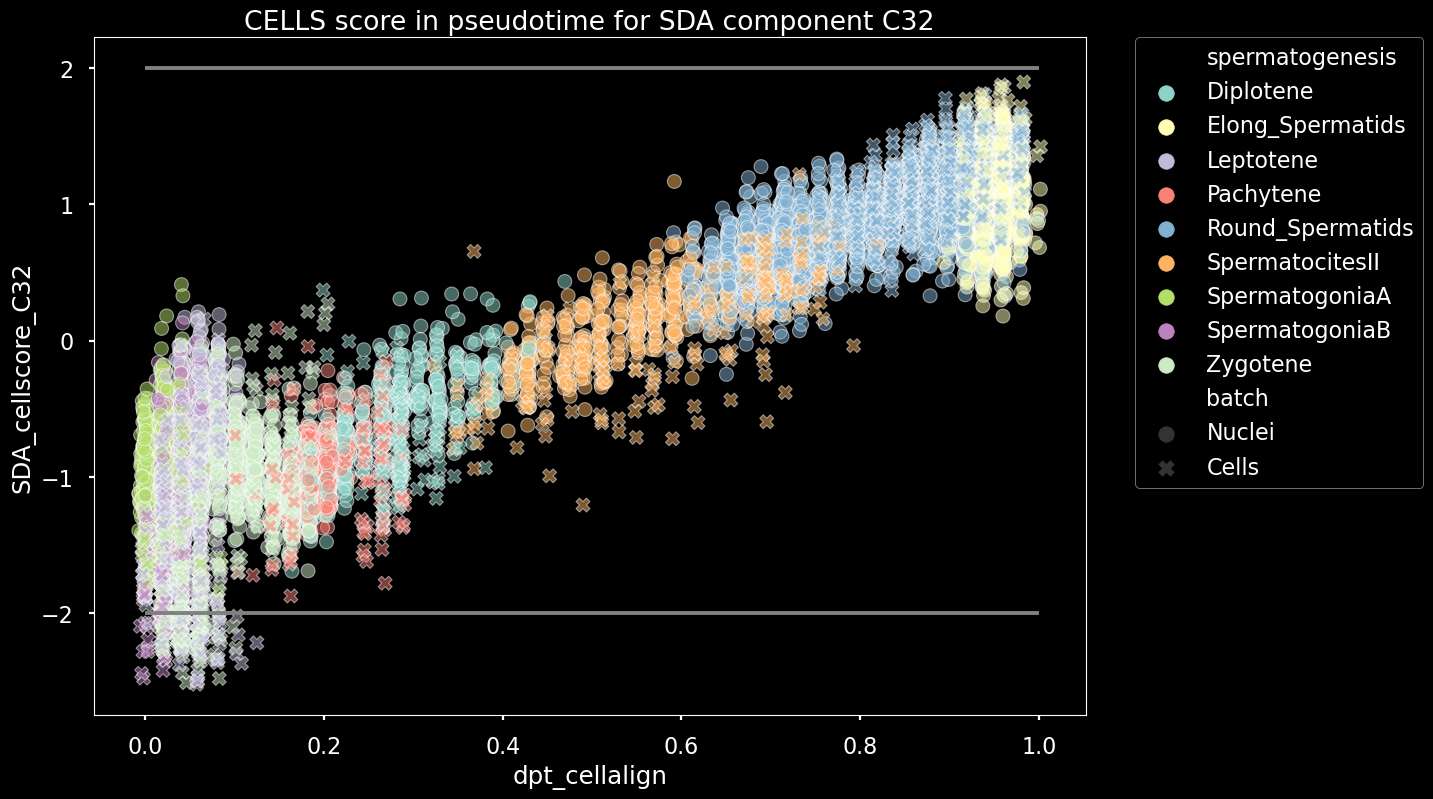

In [39]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata.obs[f'SDA_cellscore_C{comp}'],
           x=adata.obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata.shape[0]),
           hue=adata.obs['spermatogenesis'],
           style=adata.obs['batch'],
           alpha=.5, ax=ax, s=100)
plt.hlines(score_neg, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C32')

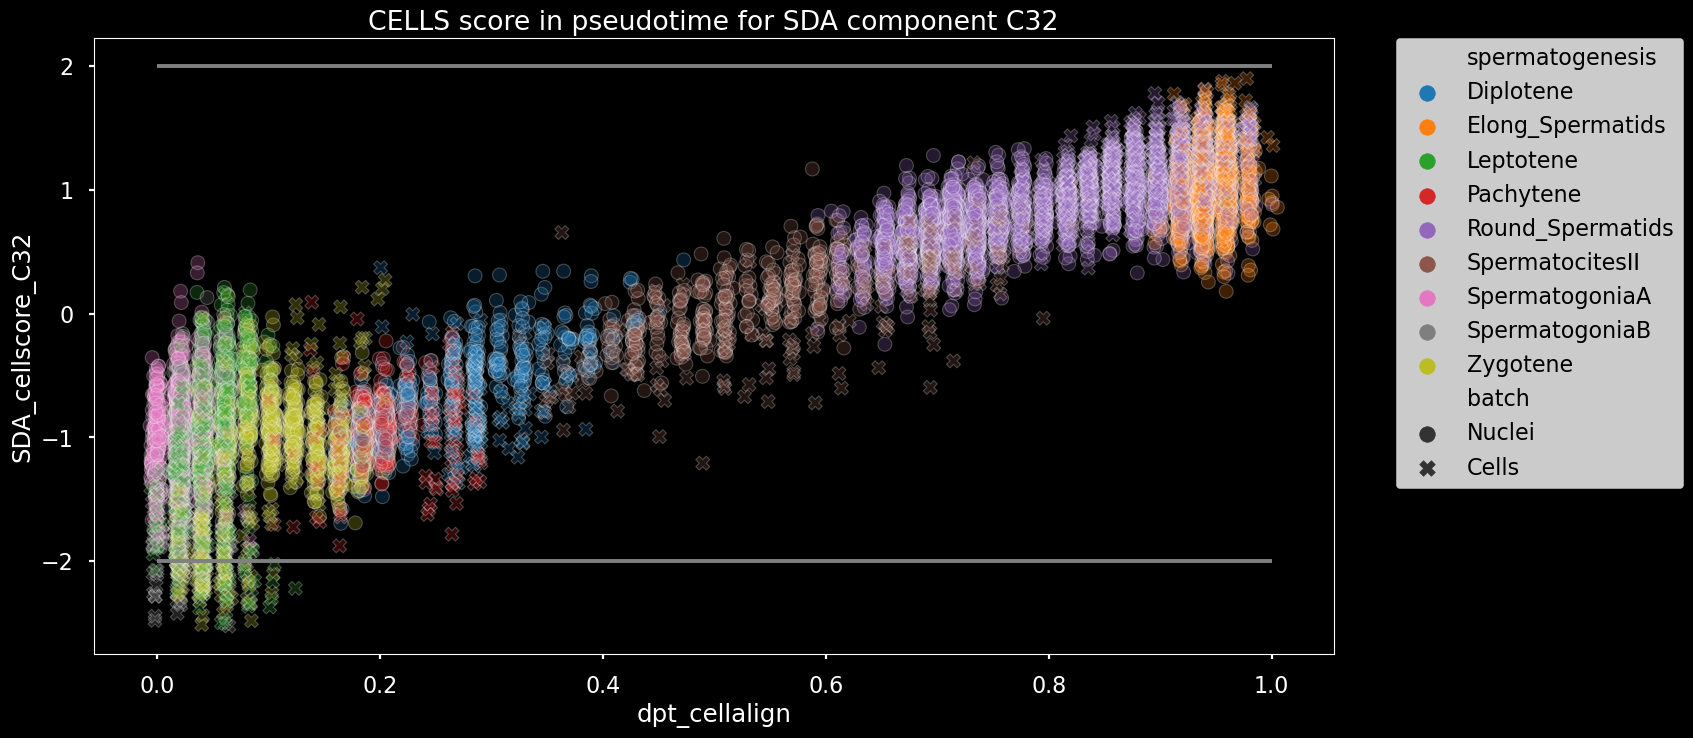

In [40]:
plt.rcParams['figure.figsize']=(16,8)
fig, ax = plt.subplots(1)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sns.scatterplot(y=adata.obs[f'SDA_cellscore_C{comp}'],
           x=adata.obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata.shape[0]),
           hue=adata.obs['spermatogenesis'],
           style=adata.obs['batch'],
           alpha=.25, ax=ax, s=100)
plt.hlines(score_neg, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

## Gene set enrichment analysis

In [41]:
import gseapy as gp

In [42]:
!mkdir -p ./enrichment

In [43]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [44]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )

In [45]:
enr.results[enr.results['Adjusted P-value']<.001]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
450,Human_Gene_Atlas,TestisIntersitial,95/568,9.764405e-31,7.323304e-29,0,0,4.887594,337.739538,TSKS;ROPN1B;CALR3;MS4A5;DYRK4;CLPB;SIRPD;ICA1;...
451,Human_Gene_Atlas,TestisGermCell,41/314,2.525606e-10,9.471022e-09,0,0,3.450920,76.263153,CALR3;CLPB;PDE1A;KLHL10;DDX20;SPATA7;HMGB4;ADA...


In [46]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [47]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None)

In [48]:
table_pos = enr.results[enr.results['Adjusted P-value']<.001][ ['Gene_set', 'Term', 'Overlap', 'Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes' ] ]

In [49]:
table_pos['Component'] = f'{comp}P'

In [50]:
table_pos['Batch diff'] = batch_effect_pos

In [51]:
table_pos['N cells'] = POSITIVE

In [52]:
table_pos

,Gene_set,Term,Overlap,Adjusted P-value,Odds Ratio,Combined Score,Genes,Component,Batch diff,N cells
450,Human_Gene_Atlas,TestisIntersitial,95/568,7.323304e-29,4.887594,337.739538,TSKS;ROPN1B;CALR3;MS4A5;DYRK4;CLPB;SIRPD;ICA1;...,32P,Yes,2
451,Human_Gene_Atlas,TestisGermCell,41/314,9.471022e-09,3.450920,76.263153,CALR3;CLPB;PDE1A;KLHL10;DDX20;SPATA7;HMGB4;ADA...,32P,Yes,2


In [53]:
table_pos.to_csv(f'enrichment/enrichr_C{comp}P.csv', header=False, index_label=False, index=None, sep='\t')

In [54]:
genes = list( adata[:,adata.var[f'sda_neg_C{comp}']].var_names )

In [55]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )

In [56]:
enr.results[enr.results['Adjusted P-value']<.001]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Ubiquitin mediated proteolysis,29/140,3.557529e-11,8.538071e-09,0,0,5.171879,124.432141,UBE3C;CUL5;UBE2D2;UBE2D3;BRCA1;RNF7;CBL;UBE2L3...
240,GO_Cellular_Component_2023,Intracellular Membrane-Bounded Organelle (GO:0...,369/5175,1.268184e-16,3.982099e-14,0,0,1.774032,64.936286,ITSN2;CHIC2;RPL3;CCNI;ZFYVE9;TRRAP;NEXMIF;SMC5...
241,GO_Cellular_Component_2023,Nucleus (GO:0005634),328/4487,5.941805e-16,9.328634e-14,0,0,1.786126,62.620431,RPL3;CCNI;TRRAP;NEXMIF;SMC5;RBPJ;GPATCH8;DCAF7...
242,GO_Cellular_Component_2023,Intracellular Non-Membrane-Bounded Organelle (...,102/1195,3.045194e-08,3.187303e-06,0,0,1.896366,32.820624,SRP19;RPL3;FBXO25;RBPJ;ACTG1;SPATA22;CDC27;ZNF...
243,GO_Cellular_Component_2023,Nuclear Lumen (GO:0031981),71/780,4.166147e-07,3.270425e-05,0,0,2.007976,29.499385,SRP19;RPL3;FBXO25;RBPJ;SMG6;XPO1;XPO6;ZNF207;K...
244,GO_Cellular_Component_2023,Chromosome (GO:0005694),24/164,1.669936e-06,1.048720e-04,0,0,3.370714,44.839687,IK;SETD2;PBRM1;ESCO1;XRCC4;NIFK;CCDC137;HP1BP3...
245,GO_Cellular_Component_2023,Nucleolus (GO:0005730),67/771,4.393559e-06,2.299296e-04,0,0,1.900503,23.443411,SRP19;RPL3;FBXO25;RBPJ;SMG6;XPO1;XPO6;ZNF207;K...
246,GO_Cellular_Component_2023,Bounding Membrane Of Organelle (GO:0098588),69/819,9.016842e-06,4.044698e-04,0,0,1.836581,21.334494,GALNT11;ARF1;MCFD2;PITPNB;SPPL2A;ATP2A2;ABCA13...
247,GO_Cellular_Component_2023,Nuclear Chromosome (GO:0000228),16/95,1.481898e-05,5.816449e-04,0,0,3.962130,44.057307,INO80C;IK;PBRM1;INO80E;NIFK;TRRAP;NCAPG;INO80;...
554,Human_Gene_Atlas,721 B lymphoblasts,128/1543,2.508479e-09,1.806105e-07,0,0,1.860018,36.835030,MTCH2;RIF1;PDCD5;UBE2D3;PAGE1;BCCIP;UBE2L3;PPP...


In [57]:
table_neg = enr.results[enr.results['Adjusted P-value']<.001][ ['Gene_set', 'Term', 'Overlap', 'Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes' ] ]

In [58]:
table_neg['Component'] = f'{comp}N'

In [59]:
table_neg['Batch diff'] = batch_effect_neg

In [60]:
table_neg['N cells'] = NEGATIVE

In [61]:
table_neg

,Gene_set,Term,Overlap,Adjusted P-value,Odds Ratio,Combined Score,Genes,Component,Batch diff,N cells
0,KEGG_2021_Human,Ubiquitin mediated proteolysis,29/140,8.538071e-09,5.171879,124.432141,UBE3C;CUL5;UBE2D2;UBE2D3;BRCA1;RNF7;CBL;UBE2L3...,32N,Yes,238
240,GO_Cellular_Component_2023,Intracellular Membrane-Bounded Organelle (GO:0...,369/5175,3.982099e-14,1.774032,64.936286,ITSN2;CHIC2;RPL3;CCNI;ZFYVE9;TRRAP;NEXMIF;SMC5...,32N,Yes,238
241,GO_Cellular_Component_2023,Nucleus (GO:0005634),328/4487,9.328634e-14,1.786126,62.620431,RPL3;CCNI;TRRAP;NEXMIF;SMC5;RBPJ;GPATCH8;DCAF7...,32N,Yes,238
242,GO_Cellular_Component_2023,Intracellular Non-Membrane-Bounded Organelle (...,102/1195,3.187303e-06,1.896366,32.820624,SRP19;RPL3;FBXO25;RBPJ;ACTG1;SPATA22;CDC27;ZNF...,32N,Yes,238
243,GO_Cellular_Component_2023,Nuclear Lumen (GO:0031981),71/780,3.270425e-05,2.007976,29.499385,SRP19;RPL3;FBXO25;RBPJ;SMG6;XPO1;XPO6;ZNF207;K...,32N,Yes,238
244,GO_Cellular_Component_2023,Chromosome (GO:0005694),24/164,1.048720e-04,3.370714,44.839687,IK;SETD2;PBRM1;ESCO1;XRCC4;NIFK;CCDC137;HP1BP3...,32N,Yes,238
245,GO_Cellular_Component_2023,Nucleolus (GO:0005730),67/771,2.299296e-04,1.900503,23.443411,SRP19;RPL3;FBXO25;RBPJ;SMG6;XPO1;XPO6;ZNF207;K...,32N,Yes,238
246,GO_Cellular_Component_2023,Bounding Membrane Of Organelle (GO:0098588),69/819,4.044698e-04,1.836581,21.334494,GALNT11;ARF1;MCFD2;PITPNB;SPPL2A;ATP2A2;ABCA13...,32N,Yes,238
247,GO_Cellular_Component_2023,Nuclear Chromosome (GO:0000228),16/95,5.816449e-04,3.962130,44.057307,INO80C;IK;PBRM1;INO80E;NIFK;TRRAP;NCAPG;INO80;...,32N,Yes,238
554,Human_Gene_Atlas,721 B lymphoblasts,128/1543,1.806105e-07,1.860018,36.835030,MTCH2;RIF1;PDCD5;UBE2D3;PAGE1;BCCIP;UBE2L3;PPP...,32N,Yes,238


In [62]:
table_neg.to_csv(f'enrichment/enrichr_C{comp}N.csv', header=False, index_label=False, index=None, sep='\t')

## Plot genes average expression for positive and negative module

In [63]:
!mkdir -p ./plots

In [64]:
adata.layers

Layers with keys: SCT_counts, correct_counts, raw_counts, scaled_counts, spliced, unspliced

In [65]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [66]:
adata.obs[f'module_pos_C{comp}'] = np.array( np.mean(adata[:,genes].layers['scaled_counts'], 1) )

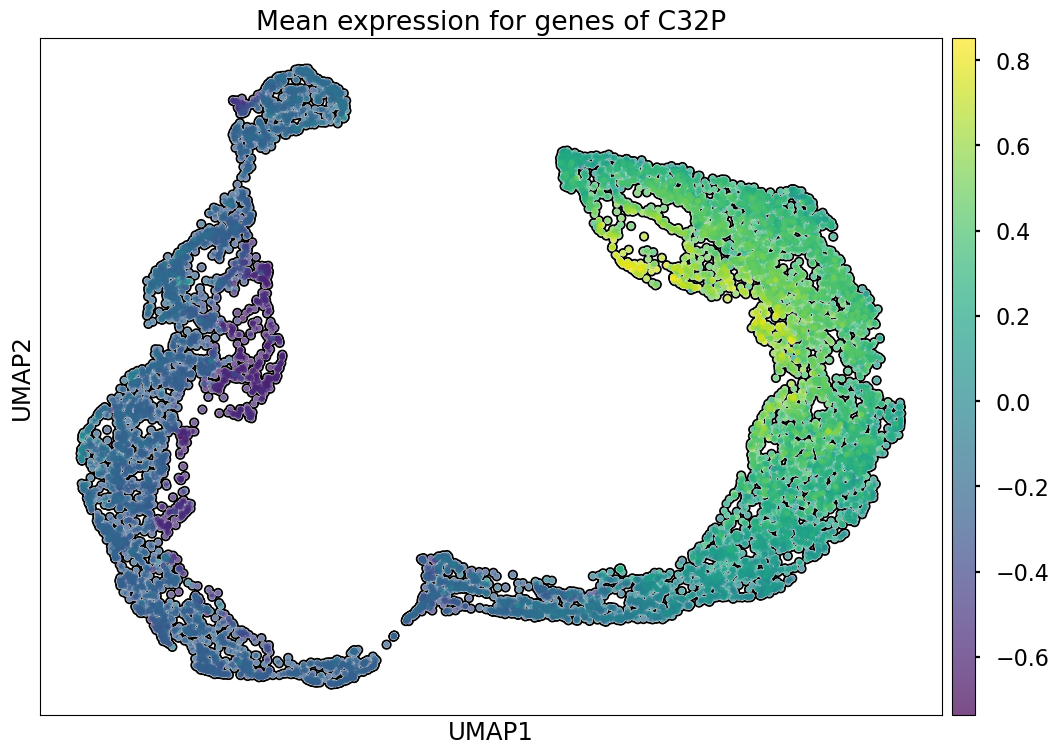

In [67]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_pos_C{comp}'], 
           add_outline=True, 
           save=f'genes_C{comp}P_white.png',
           title=f'Mean expression for genes of C{comp}P', size=75)

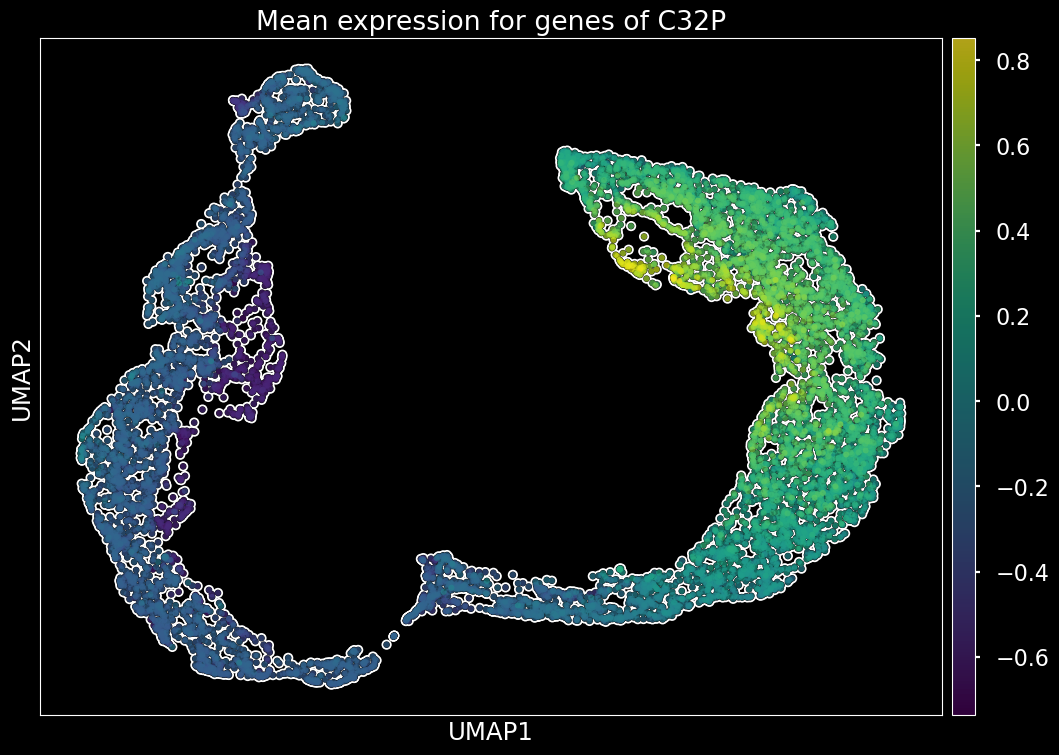

In [68]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_pos_C{comp}'], 
           add_outline=True, outline_color=['white','black'],
           save=f'genes_C{comp}P_dark.png',
           title=f'Mean expression for genes of C{comp}P', size=75)

In [69]:
genes = list( adata[:,adata.var[f'sda_neg_C{comp}']].var_names )

In [70]:
adata.obs[f'module_neg_C{comp}'] = np.array( np.mean(adata[:,genes].layers['SCT_counts'], 1) )

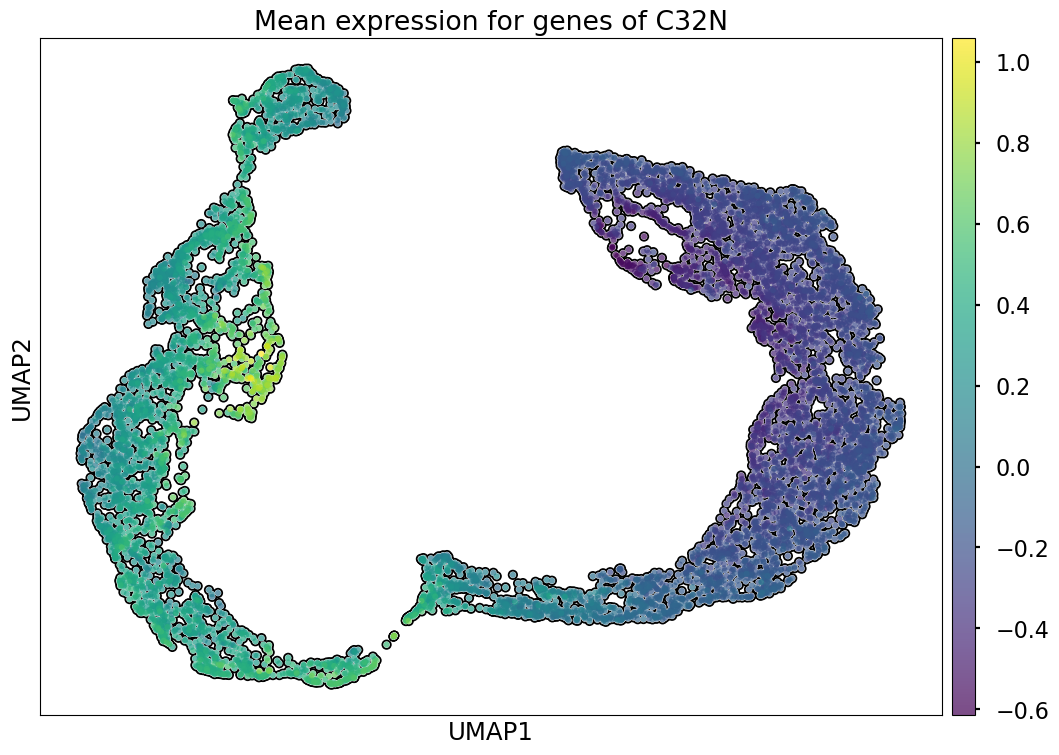

In [71]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_neg_C{comp}'], 
           add_outline=True, 
           save=f'genes_C{comp}N_white.png',
           title=f'Mean expression for genes of C{comp}N', size=75)

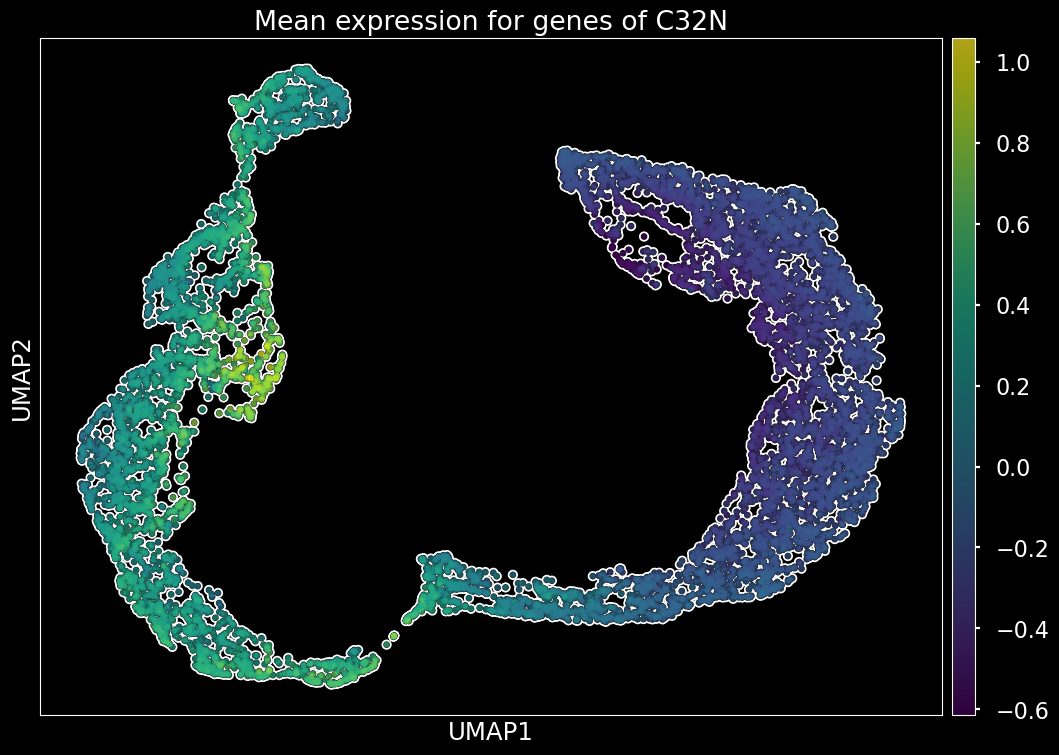

In [72]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_neg_C{comp}'], 
           add_outline=True, outline_color=['white','black'],
           save=f'genes_C{comp}N_dark.png',
           title=f'Mean expression for genes of C{comp}N', size=75)